In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

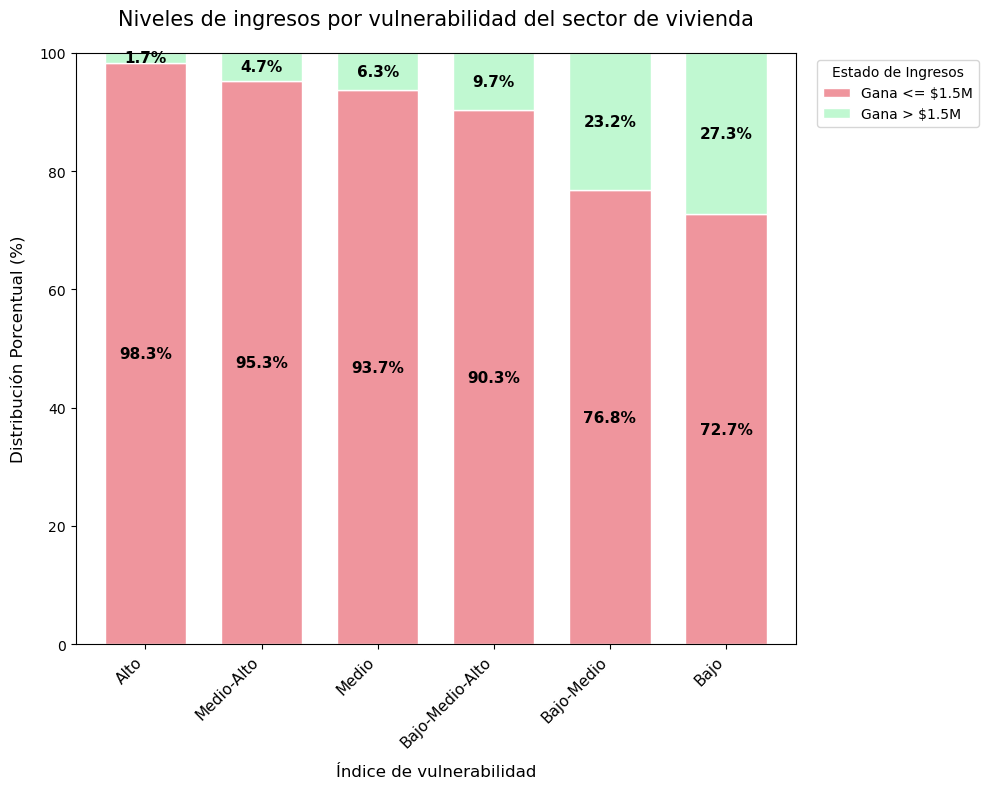

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carga de datos y filtrado
df = pd.read_parquet('../data/casen_2024.parquet')
df = df[(df['activ'] == 1) | (df['ytotcor'] > 0)].copy()

df['I_1.5'] = (df['y1'] > 1500000).astype(int)

# 2. Agrupación y mapeo de NSE
def agrupar_nse(nse):
    if pd.isna(nse): return None
    val = int(nse)
    map_nse = {
        1: 'Alto',
        2: 'Medio',
        3: 'Bajo',
        4: 'Medio-Alto',
        5: 'Bajo-Alto',
        6: 'Bajo-Medio-Alto',
        7: 'Bajo-Medio'
    }
    label = map_nse.get(val)
    if label == 'Bajo-Alto': return None  # Filtramos explícitamente el nivel Bajo-Alto
    return label
    
df['Nivel Vulnerabilidad'] = df['nse'].apply(agrupar_nse)

# Nos quedamos con los datos válidos
df_bar = df.dropna(subset=['Nivel Vulnerabilidad', 'y1']).copy()
df_bar['Status Ingreso'] = df_bar['I_1.5'].map({1: 'Gana > $1.5M', 0: 'Gana <= $1.5M'})

# 3. Cálculo de Porcentajes Ponderados
agg_df = df_bar.groupby(['Nivel Vulnerabilidad', 'Status Ingreso'])['expr'].sum().reset_index()

# Pivotamos la tabla para que sea más fácil graficar con Matplotlib
pivot_df = agg_df.pivot(index='Nivel Vulnerabilidad', columns='Status Ingreso', values='expr').fillna(0)

# Convertimos a porcentajes (cada fila sumará 100%)
pivot_pct = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

# Ordenamos por los que más ganan sobre 1.5M
pivot_pct = pivot_pct.sort_values(by='Gana > $1.5M')

# Aseguramos el orden de las columnas para el apilado
pivot_pct = pivot_pct[['Gana <= $1.5M', 'Gana > $1.5M']]

# 4. Generación del gráfico estático
fig, ax = plt.subplots(figsize=(10, 8))

# Colores (Gris y Verde oscuro)
colors = ['#EF959D', '#C0F8D1'] 

# Dibujar las barras apiladas
pivot_pct.plot(kind='bar', stacked=True, color=colors, ax=ax, edgecolor='white', width=0.7)

# Añadir etiquetas de porcentaje dentro de cada bloque de las barras
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0: # Evitar poner texto en barras vacías
        # Elegir color de fuente dependiendo de qué segmento sea para mantener legibilidad
        text_color = 'black'
        
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1f}%', 
                ha='center', 
                va='center', 
                color=text_color, 
                fontsize=11,
                fontweight='bold')

# Configuración estética del gráfico
ax.set_title("Niveles de ingresos por vulnerabilidad del sector de vivienda", fontsize=15, pad=20)
ax.set_xlabel("Índice de vulnerabilidad", fontsize=12, labelpad=10)
ax.set_ylabel("Distribución Porcentual (%)", fontsize=12, labelpad=10)
ax.set_ylim(0, 100)

# Rotar el texto del eje X para que no se superponga
plt.xticks(rotation=45, ha='right', fontsize=11)

# Posicionar la leyenda fuera del gráfico
ax.legend(title='Estado de Ingresos', bbox_to_anchor=(1.02, 1), loc='upper left')

# Evitar recortes
plt.tight_layout()

# Mostrar
plt.show()
